In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import warnings 
warnings.filterwarnings('ignore')

In [3]:
data=pd.read_csv('weather_pollution_1000.csv')

In [4]:
data.head()

,datetime,temperature,humidity,wind_speed,pressure,pm2_5
0,2024-01-01 00:00:00,30.894076,42.769890,1.441786,1008.417281,66.337316
1,2024-01-01 01:00:00,18.584180,53.538244,6.192956,993.814389,61.987653
2,2024-01-01 02:00:00,16.805544,81.092883,3.822236,1026.409389,10.321667
3,2024-01-01 03:00:00,26.539443,37.656733,7.859906,1016.720739,133.182841
4,2024-01-01 04:00:00,31.584069,83.631922,6.249263,1010.398838,103.089616


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     1000 non-null   object 
 1   temperature  1000 non-null   float64
 2   humidity     1000 non-null   float64
 3   wind_speed   1000 non-null   float64
 4   pressure     1000 non-null   float64
 5   pm2_5        1000 non-null   float64
dtypes: float64(5), object(1)
memory usage: 47.0+ KB


In [6]:
data.describe()

,temperature,humidity,wind_speed,pressure,pm2_5
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.834590,60.272081,6.169864,1010.331248,74.876797
std,8.595250,17.059168,3.536326,11.696902,42.089286
min,9.358842,28.358659,0.235054,989.512151,3.732783
25%,17.724807,45.978532,2.926395,999.642917,39.257913
50%,24.391498,59.642885,6.183385,1011.382077,75.631039
75%,31.789867,74.857376,9.351831,1020.377264,109.918747
max,40.673974,91.171985,12.171295,1030.520248,154.298469


In [7]:
data.isnull().sum()

datetime       0
temperature    0
humidity       0
wind_speed     0
pressure       0
pm2_5          0
dtype: int64

In [8]:
# تحويل ال datetime من جملة لشكل اقدر اتعامل معاة
data['datetime'] = pd.to_datetime(data['datetime'])
data['year'] = data['datetime'].dt.year
data['month'] = data['datetime'].dt.month
data['day'] = data['datetime'].dt.day
data['day_of_week'] = data['datetime'].dt.dayofweek
data['hour'] = data['datetime'].dt.hour
data

,datetime,temperature,humidity,wind_speed,pressure,pm2_5,year,month,day,day_of_week,hour
0,2024-01-01 00:00:00,30.894076,42.769890,1.441786,1008.417281,66.337316,2024,1,1,0,0
1,2024-01-01 01:00:00,18.584180,53.538244,6.192956,993.814389,61.987653,2024,1,1,0,1
2,2024-01-01 02:00:00,16.805544,81.092883,3.822236,1026.409389,10.321667,2024,1,1,0,2
3,2024-01-01 03:00:00,26.539443,37.656733,7.859906,1016.720739,133.182841,2024,1,1,0,3
4,2024-01-01 04:00:00,31.584069,83.631922,6.249263,1010.398838,103.089616,2024,1,1,0,4
...,...,...,...,...,...,...,...,...,...,...,...
995,2024-01-21 15:00:00,39.649352,45.624306,8.218732,998.346516,147.278056,2024,1,21,6,15
996,2024-01-21 16:00:00,36.035950,72.986836,3.074559,1019.250501,120.572736,2024,1,21,6,16
997,2024-01-21 17:00:00,37.502434,51.374863,2.242112,1000.472572,91.106400,2024,1,21,6,17
998,2024-01-21 18:00:00,22.089077,29.763375,11.469020,1018.777309,14.865232,2024,1,21,6,18


In [9]:
data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

In [10]:
data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)
data['day_sin'] = np.sin(2 * np.pi * data['day_of_week'] / 7)
data['day_cos'] = np.cos(2 * np.pi * data['day_of_week'] / 7)

In [11]:
data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)

In [12]:
data['temp_wind'] = data['temperature'] * data['wind_speed']
data['temp_hum'] = data['temperature'] * data['humidity']
data['hum_wind'] = data['humidity'] * data['wind_speed']
data['temp_pressure'] = data['temperature'] * data['pressure']
data

,datetime,temperature,humidity,wind_speed,pressure,pm2_5,year,month,day,day_of_week,...,month_cos,hour_sin,hour_cos,day_sin,day_cos,is_weekend,temp_wind,temp_hum,hum_wind,temp_pressure
0,2024-01-01 00:00:00,30.894076,42.769890,1.441786,1008.417281,66.337316,2024,1,1,0,...,0.866025,0.000000,1.000000e+00,0.000000,1.00000,0,44.542647,1321.336211,61.665031,31154.119675
1,2024-01-01 01:00:00,18.584180,53.538244,6.192956,993.814389,61.987653,2024,1,1,0,...,0.866025,0.258819,9.659258e-01,0.000000,1.00000,0,115.091005,994.964371,331.559978,18469.225535
2,2024-01-01 02:00:00,16.805544,81.092883,3.822236,1026.409389,10.321667,2024,1,1,0,...,0.866025,0.500000,8.660254e-01,0.000000,1.00000,0,64.234750,1362.809983,309.956120,17249.367746
3,2024-01-01 03:00:00,26.539443,37.656733,7.859906,1016.720739,133.182841,2024,1,1,0,...,0.866025,0.707107,7.071068e-01,0.000000,1.00000,0,208.597541,999.388734,295.978404,26983.202162
4,2024-01-01 04:00:00,31.584069,83.631922,6.249263,1010.398838,103.089616,2024,1,1,0,...,0.866025,0.866025,5.000000e-01,0.000000,1.00000,0,197.377167,2641.436405,522.637909,31912.506726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2024-01-21 15:00:00,39.649352,45.624306,8.218732,998.346516,147.278056,2024,1,21,6,...,0.866025,-0.707107,-7.071068e-01,-0.781831,0.62349,1,325.867413,1808.974168,374.973961,39583.792454
996,2024-01-21 16:00:00,36.035950,72.986836,3.074559,1019.250501,120.572736,2024,1,21,6,...,0.866025,-0.866025,-5.000000e-01,-0.781831,0.62349,1,110.794637,2630.149984,224.402296,36729.660392
997,2024-01-21 17:00:00,37.502434,51.374863,2.242112,1000.472572,91.106400,2024,1,21,6,...,0.866025,-0.965926,-2.588190e-01,-0.781831,0.62349,1,84.084664,1926.682408,115.188206,37520.156749
998,2024-01-21 18:00:00,22.089077,29.763375,11.469020,1018.777309,14.865232,2024,1,21,6,...,0.866025,-1.000000,-1.836970e-16,-0.781831,0.62349,1,253.340066,657.445489,341.356733,22503.850861


In [13]:
for col in ['temperature', 'humidity', 'wind_speed', 'pressure']:
    data[f'{col}_lag_1'] = data[col].shift(1)
    data[f'{col}_lag_3'] = data[col].shift(3)
    data[f'{col}_lag_6'] = data[col].shift(6)
    data[f'{col}_roll_3'] = data[col].shift(1).rolling(3).mean()
    data[f'{col}_roll_6'] = data[col].shift(1).rolling(6).mean()

In [14]:
for lag in [1, 2, 3, 6, 12, 24]:
    data[f'pm2_5_lag_{lag}'] = data['pm2_5'].shift(lag)
data

,datetime,temperature,humidity,wind_speed,pressure,pm2_5,year,month,day,day_of_week,...,pressure_lag_3,pressure_lag_6,pressure_roll_3,pressure_roll_6,pm2_5_lag_1,pm2_5_lag_2,pm2_5_lag_3,pm2_5_lag_6,pm2_5_lag_12,pm2_5_lag_24
0,2024-01-01 00:00:00,30.894076,42.769890,1.441786,1008.417281,66.337316,2024,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-01 01:00:00,18.584180,53.538244,6.192956,993.814389,61.987653,2024,1,1,0,...,NaN,NaN,NaN,NaN,66.337316,NaN,NaN,NaN,NaN,NaN
2,2024-01-01 02:00:00,16.805544,81.092883,3.822236,1026.409389,10.321667,2024,1,1,0,...,NaN,NaN,NaN,NaN,61.987653,66.337316,NaN,NaN,NaN,NaN
3,2024-01-01 03:00:00,26.539443,37.656733,7.859906,1016.720739,133.182841,2024,1,1,0,...,1008.417281,NaN,1009.547020,NaN,10.321667,61.987653,66.337316,NaN,NaN,NaN
4,2024-01-01 04:00:00,31.584069,83.631922,6.249263,1010.398838,103.089616,2024,1,1,0,...,993.814389,NaN,1012.314839,NaN,133.182841,10.321667,61.987653,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2024-01-21 15:00:00,39.649352,45.624306,8.218732,998.346516,147.278056,2024,1,21,6,...,1023.746684,1002.061873,1020.928316,1017.677702,29.457699,68.521170,80.507576,80.087269,127.108446,153.415557
996,2024-01-21 16:00:00,36.035950,72.986836,3.074559,1019.250501,120.572736,2024,1,21,6,...,1021.215558,1019.091401,1012.461593,1017.058476,147.278056,29.457699,68.521170,98.312361,92.334623,55.533642
997,2024-01-21 17:00:00,37.502434,51.374863,2.242112,1000.472572,91.106400,2024,1,21,6,...,1017.822705,1022.127993,1011.806574,1017.084993,120.572736,147.278056,29.457699,73.915983,138.954307,3.740949
998,2024-01-21 18:00:00,22.089077,29.763375,11.469020,1018.777309,14.865232,2024,1,21,6,...,998.346516,1023.746684,1006.023196,1013.475756,91.106400,120.572736,147.278056,80.507576,13.030758,124.309557


In [15]:
for window in [3, 6, 12, 24]:
    data[f'pm2_5_roll_{window}'] = data['pm2_5'].shift(1).rolling(window).mean()
    data[f'pm2_5_roll_{window}_std'] = data['pm2_5'].shift(1).rolling(window).std()
data

,datetime,temperature,humidity,wind_speed,pressure,pm2_5,year,month,day,day_of_week,...,pm2_5_lag_12,pm2_5_lag_24,pm2_5_roll_3,pm2_5_roll_3_std,pm2_5_roll_6,pm2_5_roll_6_std,pm2_5_roll_12,pm2_5_roll_12_std,pm2_5_roll_24,pm2_5_roll_24_std
0,2024-01-01 00:00:00,30.894076,42.769890,1.441786,1008.417281,66.337316,2024,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-01 01:00:00,18.584180,53.538244,6.192956,993.814389,61.987653,2024,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-01 02:00:00,16.805544,81.092883,3.822236,1026.409389,10.321667,2024,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-01 03:00:00,26.539443,37.656733,7.859906,1016.720739,133.182841,2024,1,1,0,...,NaN,NaN,46.215545,31.160998,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-01 04:00:00,31.584069,83.631922,6.249263,1010.398838,103.089616,2024,1,1,0,...,NaN,NaN,68.497387,61.688731,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2024-01-21 15:00:00,39.649352,45.624306,8.218732,998.346516,147.278056,2024,1,21,6,...,127.108446,153.415557,59.495482,26.694939,71.800343,23.045627,84.472152,40.641326,79.005545,43.392720
996,2024-01-21 16:00:00,36.035950,72.986836,3.074559,1019.250501,120.572736,2024,1,21,6,...,92.334623,55.533642,81.752308,60.014218,82.998807,38.810521,86.152953,42.918229,78.749816,42.950965
997,2024-01-21 17:00:00,37.502434,51.374863,2.242112,1000.472572,91.106400,2024,1,21,6,...,138.954307,3.740949,99.102831,61.774807,86.708870,41.535505,88.506129,44.047265,81.459778,43.471118
998,2024-01-21 18:00:00,22.089077,29.763375,11.469020,1018.777309,14.865232,2024,1,21,6,...,13.030758,124.309557,119.652397,28.097135,89.573939,41.066822,84.518804,41.134739,85.100005,40.216148


In [16]:
data['pm2_5_change'] = data['pm2_5'].shift(1) - data['pm2_5'].shift(2)

In [17]:
data.drop(['datetime', 'year', 'month', 'day', 'hour'], axis=1, inplace=True)
data

,temperature,humidity,wind_speed,pressure,pm2_5,day_of_week,month_sin,month_cos,hour_sin,hour_cos,...,pm2_5_lag_24,pm2_5_roll_3,pm2_5_roll_3_std,pm2_5_roll_6,pm2_5_roll_6_std,pm2_5_roll_12,pm2_5_roll_12_std,pm2_5_roll_24,pm2_5_roll_24_std,pm2_5_change
0,30.894076,42.769890,1.441786,1008.417281,66.337316,0,0.5,0.866025,0.000000,1.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18.584180,53.538244,6.192956,993.814389,61.987653,0,0.5,0.866025,0.258819,9.659258e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,16.805544,81.092883,3.822236,1026.409389,10.321667,0,0.5,0.866025,0.500000,8.660254e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.349663
3,26.539443,37.656733,7.859906,1016.720739,133.182841,0,0.5,0.866025,0.707107,7.071068e-01,...,NaN,46.215545,31.160998,NaN,NaN,NaN,NaN,NaN,NaN,-51.665986
4,31.584069,83.631922,6.249263,1010.398838,103.089616,0,0.5,0.866025,0.866025,5.000000e-01,...,NaN,68.497387,61.688731,NaN,NaN,NaN,NaN,NaN,NaN,122.861174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,39.649352,45.624306,8.218732,998.346516,147.278056,6,0.5,0.866025,-0.707107,-7.071068e-01,...,153.415557,59.495482,26.694939,71.800343,23.045627,84.472152,40.641326,79.005545,43.392720,-39.063470
996,36.035950,72.986836,3.074559,1019.250501,120.572736,6,0.5,0.866025,-0.866025,-5.000000e-01,...,55.533642,81.752308,60.014218,82.998807,38.810521,86.152953,42.918229,78.749816,42.950965,117.820356
997,37.502434,51.374863,2.242112,1000.472572,91.106400,6,0.5,0.866025,-0.965926,-2.588190e-01,...,3.740949,99.102831,61.774807,86.708870,41.535505,88.506129,44.047265,81.459778,43.471118,-26.705320
998,22.089077,29.763375,11.469020,1018.777309,14.865232,6,0.5,0.866025,-1.000000,-1.836970e-16,...,124.309557,119.652397,28.097135,89.573939,41.066822,84.518804,41.134739,85.100005,40.216148,-29.466336


In [18]:
data=data.dropna()
data

,temperature,humidity,wind_speed,pressure,pm2_5,day_of_week,month_sin,month_cos,hour_sin,hour_cos,...,pm2_5_lag_24,pm2_5_roll_3,pm2_5_roll_3_std,pm2_5_roll_6,pm2_5_roll_6_std,pm2_5_roll_12,pm2_5_roll_12_std,pm2_5_roll_24,pm2_5_roll_24_std,pm2_5_change
24,31.673301,43.236199,5.644633,1014.735323,126.614186,1,0.5,0.866025,0.000000,1.000000e+00,...,66.337316,46.559053,31.912278,91.418600,53.332218,87.724840,44.117332,78.512779,41.678822,57.169260
25,19.688767,49.359308,10.542896,1023.844965,112.064824,1,0.5,0.866025,0.258819,9.659258e-01,...,61.987653,78.705238,50.383842,89.132932,51.062437,90.081497,45.470173,81.024315,42.716442,43.278792
26,20.853660,38.863371,4.540609,1000.876516,42.500705,1,0.5,0.866025,0.500000,8.660254e-01,...,10.321667,107.338134,22.023162,86.527549,49.060798,91.758463,45.913916,83.110864,42.968443,-14.549362
27,16.847897,47.053154,1.249312,1029.149843,73.911142,1,0.5,0.866025,0.707107,7.071068e-01,...,133.182841,93.726572,44.955400,70.142812,43.395680,85.515795,47.183876,84.451657,41.057952,-69.564119
28,18.811421,76.754718,5.590734,1025.436959,39.127172,1,0.5,0.866025,0.866025,5.000000e-01,...,103.089616,76.158890,34.836489,77.432064,38.765837,84.828157,47.297175,81.982003,39.761445,31.410437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,39.649352,45.624306,8.218732,998.346516,147.278056,6,0.5,0.866025,-0.707107,-7.071068e-01,...,153.415557,59.495482,26.694939,71.800343,23.045627,84.472152,40.641326,79.005545,43.392720,-39.063470
996,36.035950,72.986836,3.074559,1019.250501,120.572736,6,0.5,0.866025,-0.866025,-5.000000e-01,...,55.533642,81.752308,60.014218,82.998807,38.810521,86.152953,42.918229,78.749816,42.950965,117.820356
997,37.502434,51.374863,2.242112,1000.472572,91.106400,6,0.5,0.866025,-0.965926,-2.588190e-01,...,3.740949,99.102831,61.774807,86.708870,41.535505,88.506129,44.047265,81.459778,43.471118,-26.705320
998,22.089077,29.763375,11.469020,1018.777309,14.865232,6,0.5,0.866025,-1.000000,-1.836970e-16,...,124.309557,119.652397,28.097135,89.573939,41.066822,84.518804,41.134739,85.100005,40.216148,-29.466336


In [19]:
data.drop(['month_sin', 'month_cos'], axis=1, inplace=True)

In [20]:
X = data.drop('pm2_5', axis=1)
y = data['pm2_5']

print("=" * 70)
print("GRADIENT BOOSTING OPTIMIZATION FOR PM2.5 PREDICTION")
print("=" * 70)
print(f"Total samples: {len(data)}")
print(f"Total features: {X.shape[1]}")
print("=" * 70)

GRADIENT BOOSTING OPTIMIZATION FOR PM2.5 PREDICTION
Total samples: 976
Total features: 49


<Axes: xlabel='humidity', ylabel='pm2_5'>

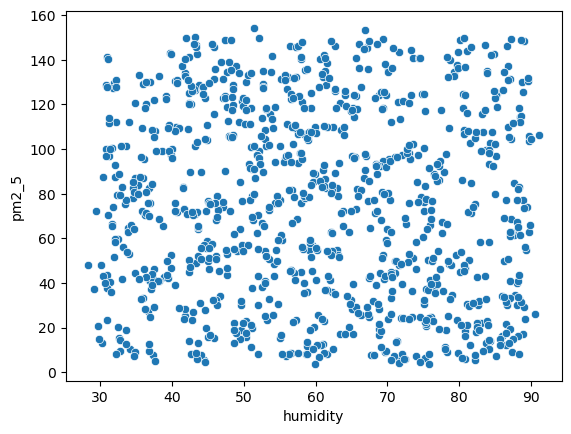

In [21]:
sns.scatterplot(x="humidity",y="pm2_5",data=data)

<Axes: xlabel='pm2_5', ylabel='pm2_5'>

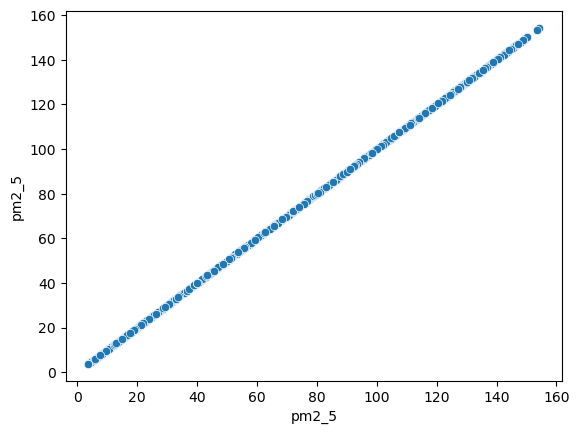

In [22]:
# لو العلاقة حط مستقيم صاعد كدا علاقة قوية ولو خط مستقيم نازل العلاقة عكسية قوية ولو النقط مبعثرة الاعلاقة ضعيفة 
sns.scatterplot(x="pm2_5",y="pm2_5",data=data)

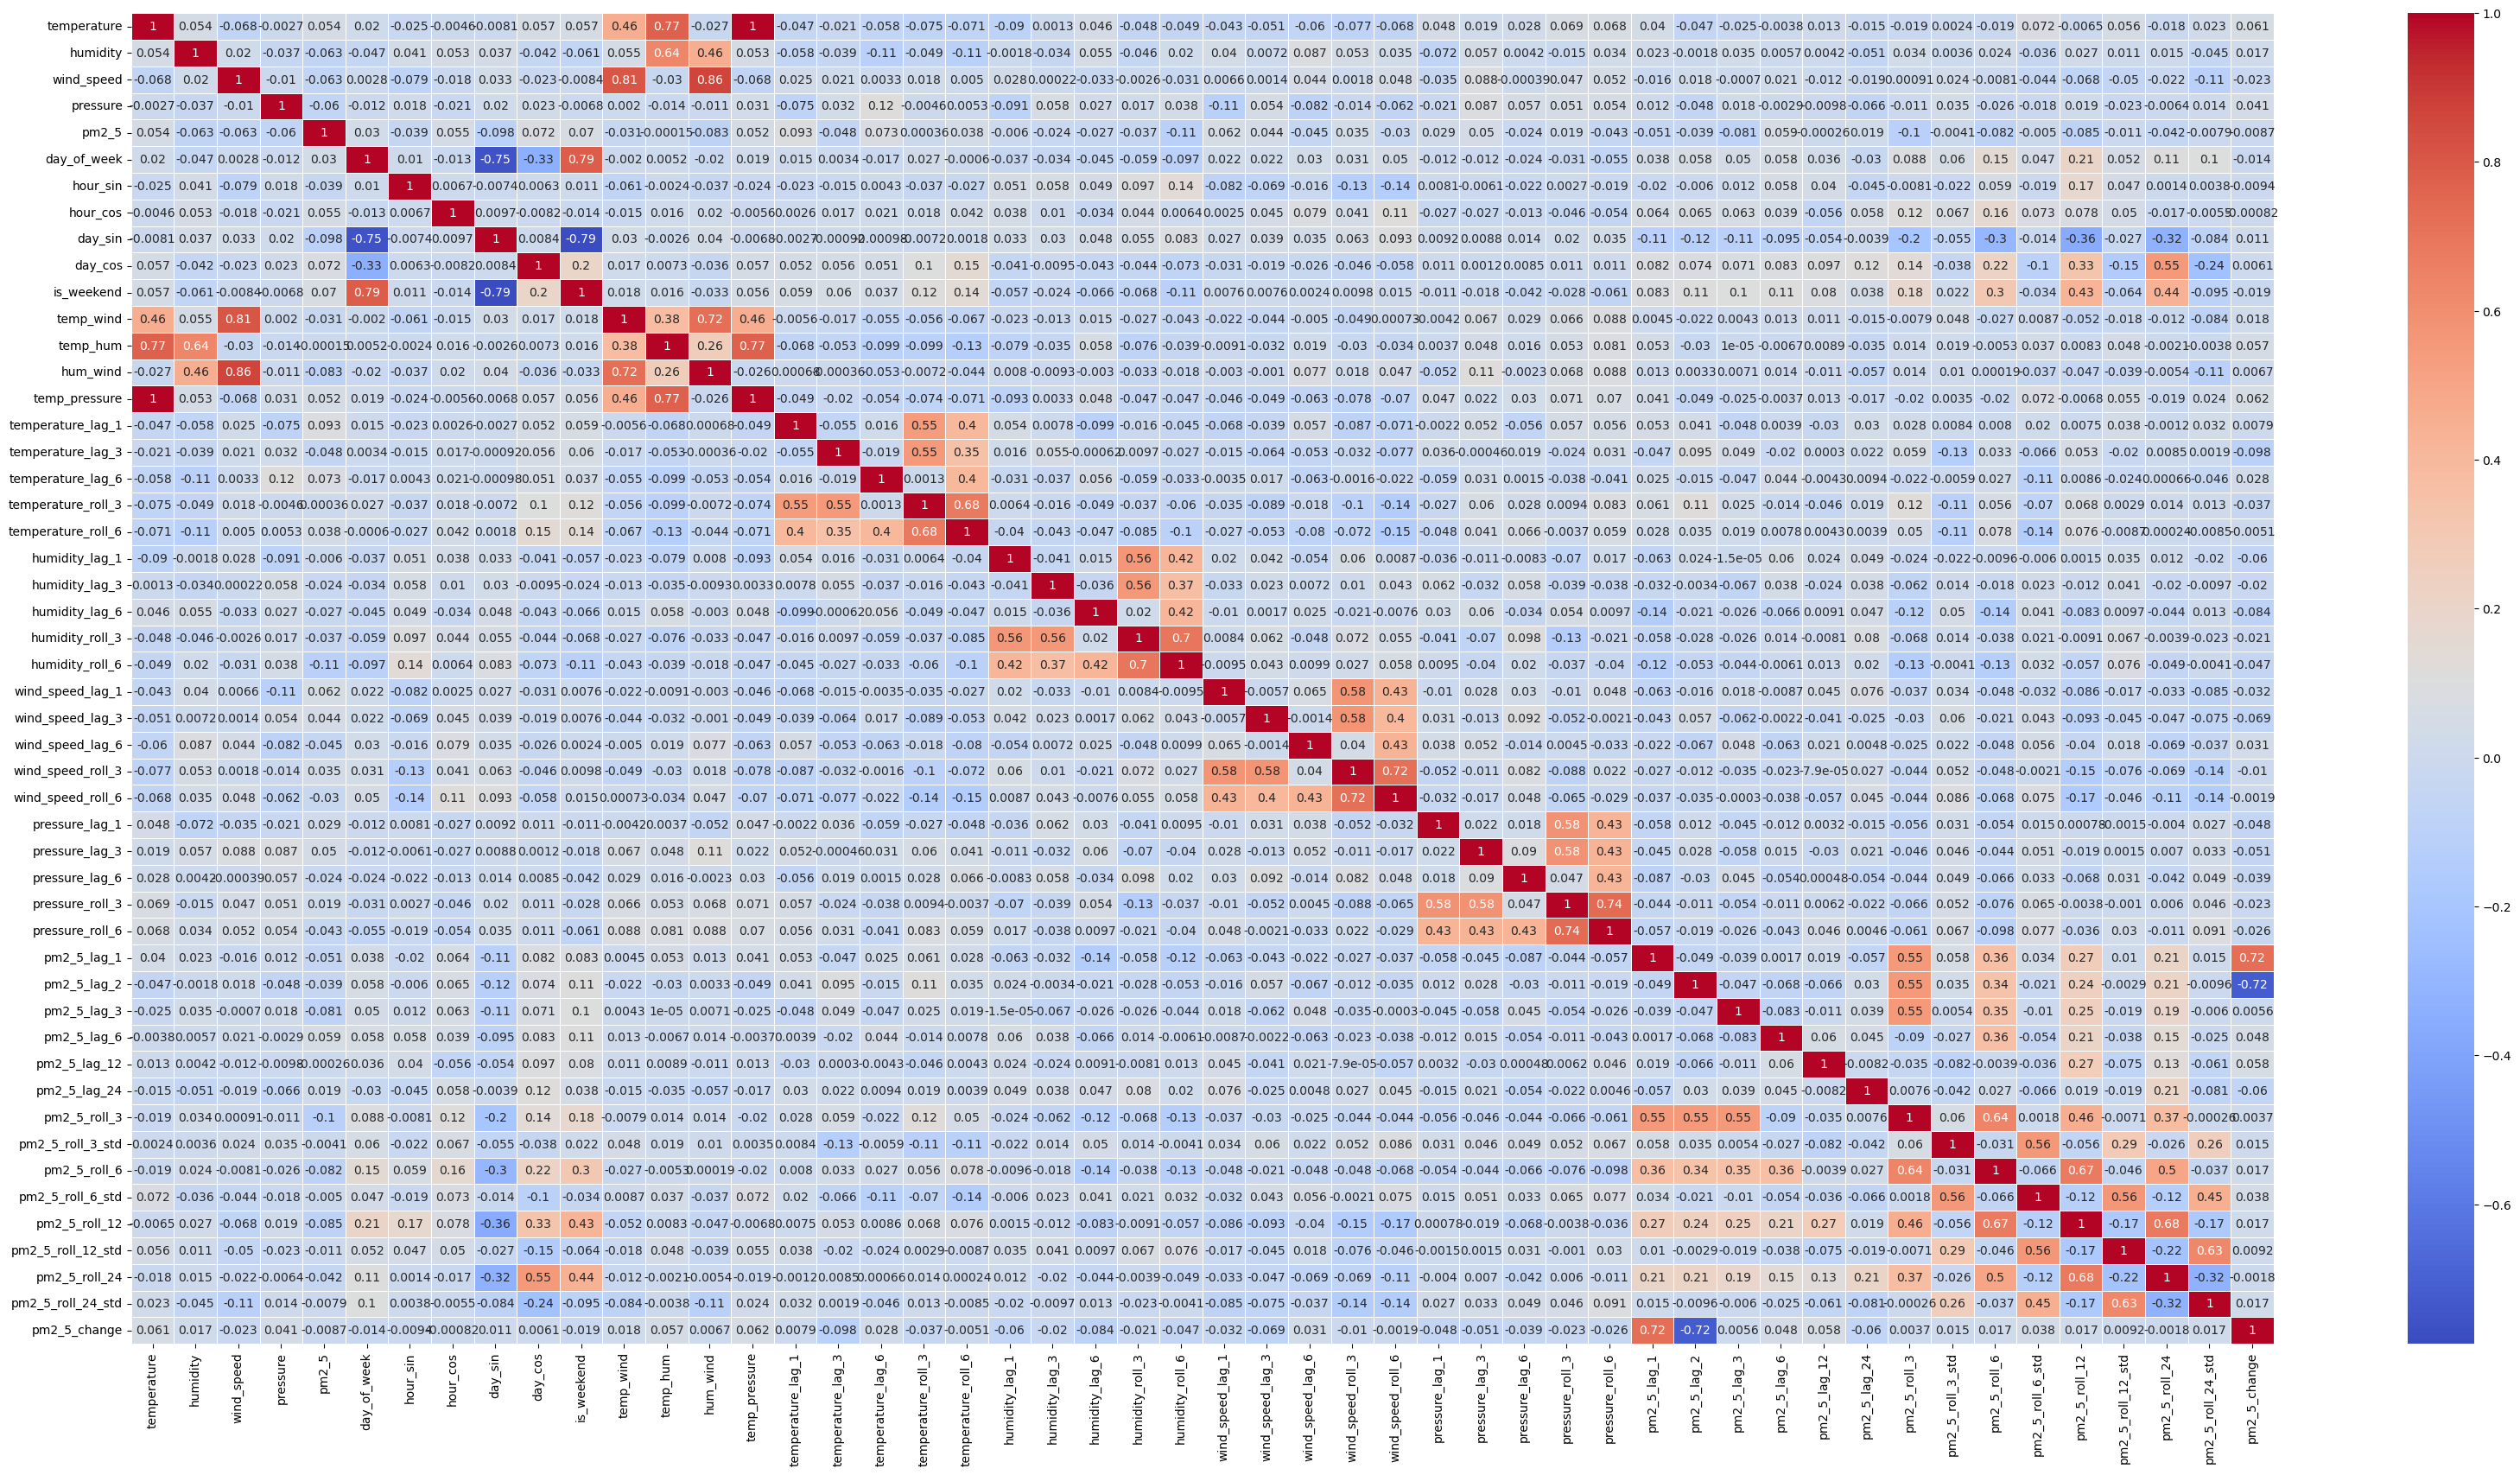

<Figure size 5000x5000 with 0 Axes>

In [23]:
plt.figure(figsize=(40,20))
sns.heatmap(data.corr(),annot=True,cmap="coolwarm", linewidth=0.5)
plt.figure(figsize=(50,50))
plt.show()

In [24]:
feature_cols = [
    'temperature', 'humidity', 'wind_speed', 'pressure',
    'day_of_week', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'temp_hum', 'temp_wind', 'hum_wind',
    'temperature_lag_1',   # NOT temp_lag_1
    'temperature_roll_3',  # NOT temp_roll_3
    'humidity_lag_1',      
    'pressure_lag_1',
    'wind_speed_lag_1',    
    'pm2_5_lag_1', 'pm2_5_lag_2', 'pm2_5_lag_3', 'pm2_5_lag_6',
    'pm2_5_roll_3', 'pm2_5_roll_6', 'pm2_5_roll_12'
]
X = data[feature_cols]
y = data['pm2_5']


In [25]:
# train = data[:int(len(data)*0.8)]
# test  = data[int(len(data)*0.8):]
split = int(len(data) * 0.8)
X_train = X.iloc[:split]
y_train = y.iloc[:split]
X_test = X.iloc[split:]
y_test = y.iloc[split:]

In [26]:
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 780
Testing samples: 196


In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
print("\n" + "=" * 70)
print("STEP 1: BASELINE GRADIENT BOOSTING MODEL")
print("=" * 70)

baseline_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
baseline_model.fit(X_train_scaled, y_train)
baseline_pred = baseline_model.predict(X_test_scaled)

baseline_r2 = r2_score(y_test, baseline_pred)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline MAE:  {baseline_mae:.4f}")
print(f"Baseline R²:   {baseline_r2:.4f}")


STEP 1: BASELINE GRADIENT BOOSTING MODEL
Baseline RMSE: 20.6185
Baseline MAE:  16.4813
Baseline R²:   0.7735


In [29]:
print("\n" + "=" * 70)
print("STEP 2: HYPERPARAMETER TUNING (This may take a few minutes...)")
print("=" * 70)

param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.05, 0.1, 0.15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 0.9, 1.0]
}


STEP 2: HYPERPARAMETER TUNING (This may take a few minutes...)


In [30]:
tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

Fitting 3 folds for each of 432 candidates, totalling 1296 fits

Best parameters found:
  learning_rate: 0.05
  max_depth: 7
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 400
  subsample: 0.8


In [31]:
print("\n" + "=" * 70)
print("STEP 3: OPTIMIZED MODEL PERFORMANCE")
print("=" * 70)

optimized_model = grid_search.best_estimator_
optimized_pred = optimized_model.predict(X_test_scaled)

opt_r2 = r2_score(y_test, optimized_pred)
opt_mae = mean_absolute_error(y_test, optimized_pred)
opt_rmse = np.sqrt(mean_squared_error(y_test, optimized_pred))

print(f"Optimized RMSE: {opt_rmse:.4f}")
print(f"Optimized MAE:  {opt_mae:.4f}")
print(f"Optimized R²:   {opt_r2:.4f}")


STEP 3: OPTIMIZED MODEL PERFORMANCE
Optimized RMSE: 12.2974
Optimized MAE:  9.5146
Optimized R²:   0.9194


In [32]:
improvement = ((opt_r2 - baseline_r2) / baseline_r2) * 100
print(f"\nImprovement: {improvement:+.2f}% in R²")


Improvement: +18.87% in R²


In [33]:
print("\n" + "=" * 70)
print("TOP 15 MOST IMPORTANT FEATURES")
print("=" * 70)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': optimized_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(15).to_string(index=False))


TOP 15 MOST IMPORTANT FEATURES
           feature  importance
 temperature_lag_1    0.079815
     pm2_5_roll_12    0.072558
          pressure    0.061267
    humidity_lag_1    0.056567
          humidity    0.056101
       pm2_5_lag_6    0.052345
       pm2_5_lag_2    0.052039
       pm2_5_lag_1    0.050702
      pm2_5_roll_3    0.049396
      pm2_5_roll_6    0.047066
temperature_roll_3    0.045634
       temperature    0.043067
    pressure_lag_1    0.040860
  wind_speed_lag_1    0.040594
       pm2_5_lag_3    0.040047


In [34]:
print("\n" + "=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)

errors = y_test - optimized_pred
print(f"Mean Error (bias):        {errors.mean():.4f}")
print(f"Std Dev of Errors:        {errors.std():.4f}")
print(f"Max Overestimation:       {errors.min():.4f}")
print(f"Max Underestimation:      {errors.max():.4f}")



ERROR ANALYSIS
Mean Error (bias):        0.4818
Std Dev of Errors:        12.3194
Max Overestimation:       -41.4499
Max Underestimation:      34.1645


In [35]:
print("\n" + "=" * 70)
print("PERFORMANCE BY PM2.5 LEVEL")
print("=" * 70)

ranges = [
    (0, 50, "Good (0-50)"),
    (50, 100, "Moderate (50-100)"),
    (100, 150, "Unhealthy for Sensitive (100-150)"),
    (150, 1000, "Unhealthy+ (150+)")
]

for low, high, label in ranges:
    mask = (y_test >= low) & (y_test < high)
    if mask.sum() > 0:
        range_r2 = r2_score(y_test[mask], optimized_pred[mask])
        range_mae = mean_absolute_error(y_test[mask], optimized_pred[mask])
        print(f"{label:35s} | Samples: {mask.sum():4d} | R²: {range_r2:.4f} | MAE: {range_mae:.4f}")


PERFORMANCE BY PM2.5 LEVEL
Good (0-50)                         | Samples:   68 | R²: -0.1813 | MAE: 11.6764
Moderate (50-100)                   | Samples:   61 | R²: 0.8225 | MAE: 4.4883
Unhealthy for Sensitive (100-150)   | Samples:   65 | R²: 0.0170 | MAE: 11.4887
Unhealthy+ (150+)                   | Samples:    2 | R²: -246.2487 | MAE: 25.1610


R²: 0.8854

GENERATING VISUALIZATIONS...


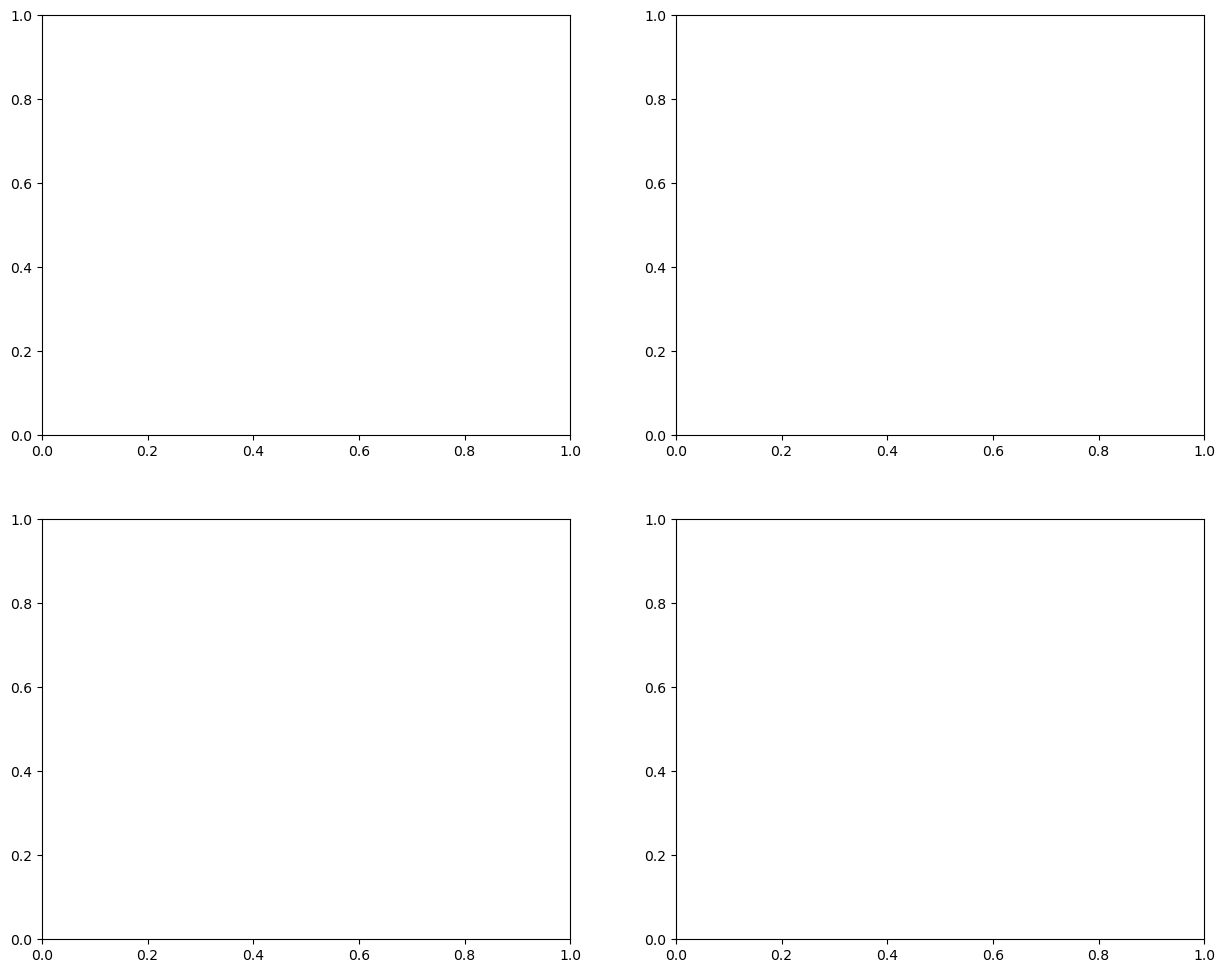

In [36]:
optimized_model = GradientBoostingRegressor(
    n_estimators=300, 
    max_depth=6, 
    learning_rate=0.1,
    random_state=42
)
optimized_model.fit(X_train_scaled, y_train)
optimized_pred = optimized_model.predict(X_test_scaled)

opt_r2 = r2_score(y_test, optimized_pred)
opt_mae = mean_absolute_error(y_test, optimized_pred)
opt_rmse = np.sqrt(mean_squared_error(y_test, optimized_pred))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': optimized_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"R²: {opt_r2:.4f}")
print("\n" + "=" * 70)
print("GENERATING VISUALIZATIONS...")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

In [37]:
axes[0, 0].scatter(y_test, optimized_pred, alpha=0.5, s=10, c='blue', edgecolors='none')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual PM2.5', fontsize=12)
axes[0, 0].set_ylabel('Predicted PM2.5', fontsize=12)
axes[0, 0].set_title(f'Actual vs Predicted (R² = {opt_r2:.4f})', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residual plot
axes[0, 1].scatter(optimized_pred, errors, alpha=0.5, s=10, c='green', edgecolors='none')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted PM2.5', fontsize=12)
axes[0, 1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[0, 1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Time series comparison
sample_size = min(200, len(y_test))
axes[1, 0].plot(range(sample_size), y_test.values[-sample_size:], 
                label='Actual', alpha=0.8, linewidth=2, color='blue')
axes[1, 0].plot(range(sample_size), optimized_pred[-sample_size:], 
                label='Predicted', alpha=0.8, linewidth=2, color='orange')
axes[1, 0].set_xlabel('Time Step', fontsize=12)
axes[1, 0].set_ylabel('PM2.5', fontsize=12)
axes[1, 0].set_title(f'Last {sample_size} Predictions', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

In [38]:
top_features = feature_importance.head(15)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
axes[1, 1].barh(range(len(top_features)), top_features['importance'], color=colors)
axes[1, 1].set_yticks(range(len(top_features)))
axes[1, 1].set_yticklabels(top_features['feature'], fontsize=9)
axes[1, 1].set_xlabel('Importance', fontsize=12)
axes[1, 1].set_title('Top 15 Feature Importance', fontsize=14, fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("OPTIMIZATION COMPLETE!")
print("=" * 70)
print(f"Final Model Performance:")
print(f"  R² Score: {opt_r2:.4f}")
print(f"  RMSE: {opt_rmse:.4f}")
print(f"  MAE: {opt_mae:.4f}")
print("=" * 70)

<Figure size 640x480 with 0 Axes>


OPTIMIZATION COMPLETE!
Final Model Performance:
  R² Score: 0.8854
  RMSE: 14.6654
  MAE: 10.9142
